# ERA5 Reanalysis Data Workflow

---

## Overview

ERA5 is ECMWF's fifth-generation global atmospheric reanalysis, covering 1940–present at 0.25° resolution. GDEX hosts ERA5 as dataset `d633000` (pressure-level) and related variants. This notebook demonstrates how to access and analyze ERA5 data from GDEX.

1. Locate ERA5 on GDEX and inspect its metadata
2. Access ERA5 data (ARCO/Zarr or THREDDS)
3. Compute a basic diagnostic (e.g., seasonal 2-m temperature)
4. Visualize the result

## Overview

[ERA5](https://confluence.ecmwf.int/display/CKB/ERA5) is ECMWF's fifth-generation
global atmospheric reanalysis, covering 1940–present at roughly 0.25° (~31 km)
resolution. GDEX hosts ERA5 as dataset [`d633000`](https://gdex.ucar.edu/datasets/d633000/).

In this notebook we access ERA5 **precipitation** directly from GDEX's
Analysis-Ready, Cloud-Optimized (ARCO) **Zarr** stores — no bulk downloads and no
intake-ESM catalog. We then make a quick map and a zonal-mean diagnostic.

1. Discover ERA5 ARCO precipitation variables on GDEX through the API
2. Open a cloud-optimized Zarr store directly with `xarray`
3. Subset a global precipitation field for a chosen time
4. Convert units and visualize precipitation on a map
5. Compute a simple diagnostic (zonal-mean precipitation)

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| zarr_intro or tds_intro | Necessary | At least one GDEX access method |
| [xarray](https://xarray.pydata.org) | Necessary | |
| [Dask](https://dask.org) | Helpful | For large time ranges |
| [cartopy](https://scitools.org.uk/cartopy) | Helpful | Mapping |

- **Time to learn**: 30 minutes

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Introduction to ARCO/Zarr on GDEX](../services/zarr_intro.ipynb) | Necessary | Opening Zarr stores on GDEX |
| [xarray](https://docs.xarray.dev) | Necessary | Labeled N-D arrays |
| [Cartopy](https://scitools.org.uk/cartopy) | Necessary | Mapping |
| [Dask](https://dask.org) | Helpful | Larger-than-memory subsets |
| [ARCO ERA5 Cookbook](https://projectpythia.org/ARCO-ERA5-cookbook/) | Helpful | Companion cookbook on the ARCO ERA5 dataset |

- **Time to learn**: 30 minutes

---

## Imports

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## ERA5 on GDEX

GDEX publishes selected datasets in **ARCO** form — chunked, indexed Zarr stores or virtual zarr stores 
that support fast remote, partial reads. For ERA5 (`d633000`), the precipitation
fields are exposed as [**kerchunk**](https://fsspec.github.io/kerchunk/) reference
files: small JSON "indexes" that point into the underlying archive and let
`xarray` treat the whole collection as a single Zarr store.

The practical upshot: we open the data lazily over HTTPS and only the bytes we
actually use get transferred — no need to download full files.


| Dataset ID | Description |
| --- | --- |
| `d633000` | ERA5 reanalysis on the 0.25° lat–lon grid — surface, pressure-level, and forecast/mean-flux fields (precipitation lives here) |
| `d633006` | ERA5 reanalysis **model-level** data on the native ~0.28° grid |

## Loading the ERA5 precipitation reference file

This notebook assumes you've already identified the kerchunk reference file for
the variable you want. There are a few ways to find it:

- **Programmatically**, through the GDEX API — see the [API notebooks](../services/api_intro.ipynb)
  and the ARCO discovery endpoints (`has_arco`, `search_arco_vars`) demonstrated in
  [Introduction to ARCO/Zarr on GDEX](../services/zarr_intro.ipynb).
- **Via the dataset's intake-ESM catalog** — `d633000` ships one at
  [`d633000-https.json`](https://data.gdex.ucar.edu/d633000/catalogs/d633000-https.json),
  which lets you search variables and look up their reference files. Note this is
  available for *this* dataset but **not all** GDEX datasets have a catalog.
- **Interactively**, by searching the [`d633000` dataset homepage](https://gdex.ucar.edu/datasets/d633000/).


Here we use **MTPR** — *Mean total precipitation rate*, a surface mean-flux field
combining convective and large-scale precipitation. Its reference file is:

In [21]:
reference_url = ("https://data.gdex.ucar.edu/d633000/kerchunk/meanflux/Mean_total_precipitation_rate-osdf.json")
reference_url

'https://data.gdex.ucar.edu/d633000/kerchunk/meanflux/Mean_total_precipitation_rate-osdf.json'

In [22]:
%%time
ds = xr.open_dataset(reference_url, engine ='kerchunk')
ds

CPU times: user 683 ms, sys: 164 ms, total: 847 ms
Wall time: 3.13 s


<xarray.Dataset> Size: 3TB
Dimensions:                (forecast_initial_time: 61666, forecast_hour: 12,
                            latitude: 721, longitude: 1440)
Coordinates:
  * forecast_initial_time  (forecast_initial_time) datetime64[ns] 493kB 1940-...
  * forecast_hour          (forecast_hour) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude               (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude              (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    MTPR                   (forecast_initial_time, forecast_hour, latitude, longitude) float32 3TB ...
    utc_date               (forecast_initial_time) int32 247kB ...
Attributes:
    CONVERSION_DATE:      Wed Nov  2 10:03:48 MDT 2022
    CONVERSION_PLATFORM:  Linux r3i0n28 4.12.14-95.51-default #1 SMP Fri Apr ...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.0.3 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.8.1
    history:              Wed Nov  2 10:03:57 2022: ncks -4 --ppc default=7 e...

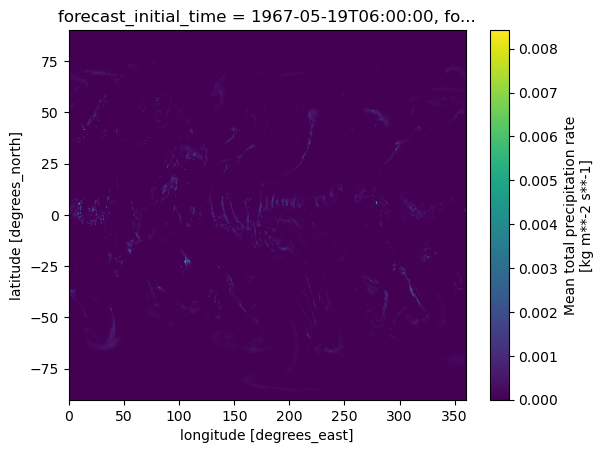

In [23]:
ds.MTPR.isel(forecast_initial_time=20000, forecast_hour=5).plot()

## Accessing ERA5 Data

In [ ]:
# TODO: open ERA5 via ARCO/Zarr or OPeNDAP
# ds = xr.open_zarr("https://...", chunks="auto")  # ARCO store
# -- or --
# ds = xr.open_dataset("https://thredds.rda.ucar.edu/thredds/dodsC/...")  # OPeNDAP

## Computing a Diagnostic

Example: compute the 2020 annual-mean 2-metre temperature over Europe.

In [ ]:
# TODO: compute annual mean temperature
# t2m = ds["2m_temperature"].sel(
#     latitude=slice(71, 34), longitude=slice(-25, 45),
#     time=slice("2020", "2020")
# )
# annual_mean = t2m.mean(dim="time").compute()

## Visualization

In [ ]:
# TODO: plot the result
# fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
# annual_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdBu_r")
# ax.coastlines()
# ax.set_title("ERA5 2020 Annual Mean 2-m Temperature")
# plt.show()

---

## Summary

ERA5 on GDEX is accessible via ARCO/Zarr for cloud-optimized analysis or via THREDDS OPeNDAP for remote subsetting. Dataset IDs d633000 and d633006 cover pressure-level and single-level fields respectively.

### What's next?

See `jra3q.ipynb` for a parallel workflow with JRA-3Q, or `data_fusion.ipynb` to combine ERA5 with another dataset.

## Resources and References

- [ERA5 documentation (ECMWF)](https://confluence.ecmwf.int/display/CKB/ERA5)
- [GDEX ERA5 dataset page](https://gdex.ucar.edu/datasets/ds633-0/)
- [xarray documentation](https://xarray.pydata.org)